<a href="https://colab.research.google.com/github/pinnekermarcel/UFC-BinaryTree/blob/main/UFC_BinaryTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Genauigkeit: 95%


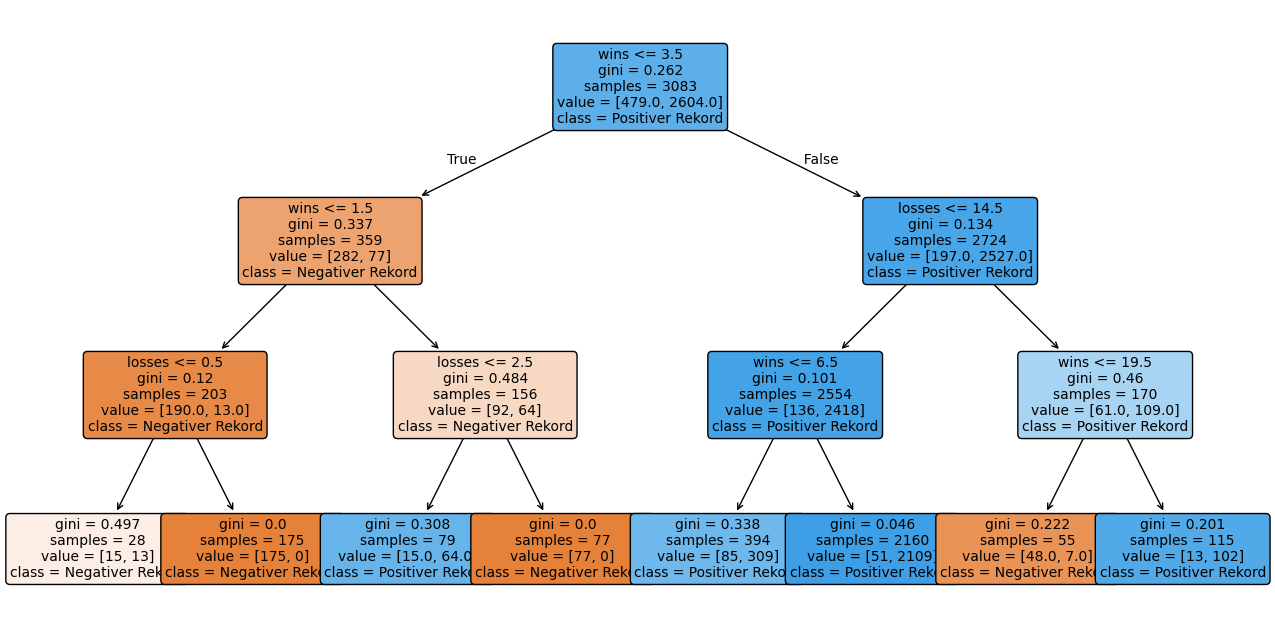

In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/ufc-fighters-statistics.csv')
df.head()
#Zielvariable erstellen
df["is_positive_record"] = (df["wins"] > df["losses"]).astype(int)

#Features auswählen
FEATURES = ["wins", "losses", "draws", "height_cm", "weight_in_kg"]
X = df[FEATURES]
y = df["is_positive_record"]

X = X.fillna(0)

#Train/test-Split
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
#Entscheidungbam trainieren
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
#Genauigkeit ausgeben
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, tree.predict(X_test))
print(f"Genauigkeit: {acc:.0%}")

#baum visualisieren
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=["Negativer Rekord", "Positiver Rekord"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()





In [4]:
df.head()

,name,nickname,wins,losses,draws,height_cm,weight_in_kg,reach_in_cm,stance,date_of_birth,significant_strikes_landed_per_minute,significant_striking_accuracy,significant_strikes_absorbed_per_minute,significant_strike_defence,average_takedowns_landed_per_15_minutes,takedown_accuracy,takedown_defense,average_submissions_attempted_per_15_minutes,is_positive_record
0,Robert Drysdale,NaN,7,0,0,190.50,92.99,NaN,Orthodox,1981-10-05,0.00,0.0,0.00,0.0,7.32,100.0,0.0,21.9,1
1,Daniel McWilliams,The Animal,15,37,0,185.42,83.91,NaN,NaN,NaN,3.36,77.0,0.00,0.0,0.00,0.0,100.0,21.6,0
2,Dan Molina,NaN,13,9,0,177.80,97.98,NaN,NaN,NaN,0.00,0.0,5.58,60.0,0.00,0.0,0.0,20.9,1
3,Paul Ruiz,NaN,7,4,0,167.64,61.23,NaN,NaN,NaN,1.40,33.0,1.40,75.0,0.00,0.0,100.0,20.9,1
4,Collin Huckbody,All In,8,2,0,190.50,83.91,193.04,Orthodox,1994-09-29,2.05,60.0,2.73,42.0,10.23,100.0,0.0,20.4,1
